# Frequency kernel response

Kernel PSD Visualization for model ablation studies.

In [1]:
import random, numpy as np, torch
import mne

%load_ext autoreload
%autoreload 2 

mne.set_log_level("ERROR")
# ---------- reproducibility ----------
RANDOM_STATE = 60
def set_seeds(seed=RANDOM_STATE):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seeds()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device in uso:", DEVICE)

Device in uso: cuda


In [2]:
# ================================================================
# Global variables config
# ================================================================
# Data / protocol
N_CHANNELS          = 16#64
SAMPLING_FREQ       = 160
EVENT_DURATION_SEC  = 4.0          # durata epoch “macro”
ALL_SUBJECTS        = [s for s in range(1, 110)
                       if s not in (89, 92, 100, 104)]

# Architecture
N_BRANCHES           = 4
DEPTH_PER_BRANCH     = 2
START_KERNEL_SIZE    = 15
KERNEL_INCREMENT     = 2

LSTM_HIDDEN_SIZE     = 32#768
CLASSIFIER_HIDDEN_DIM= 32#384

## Kernel PSD plot

N-Branches : 4
N-Branches : 4
N-Branches : 4
N-Branches : 4
N-Branches : 4


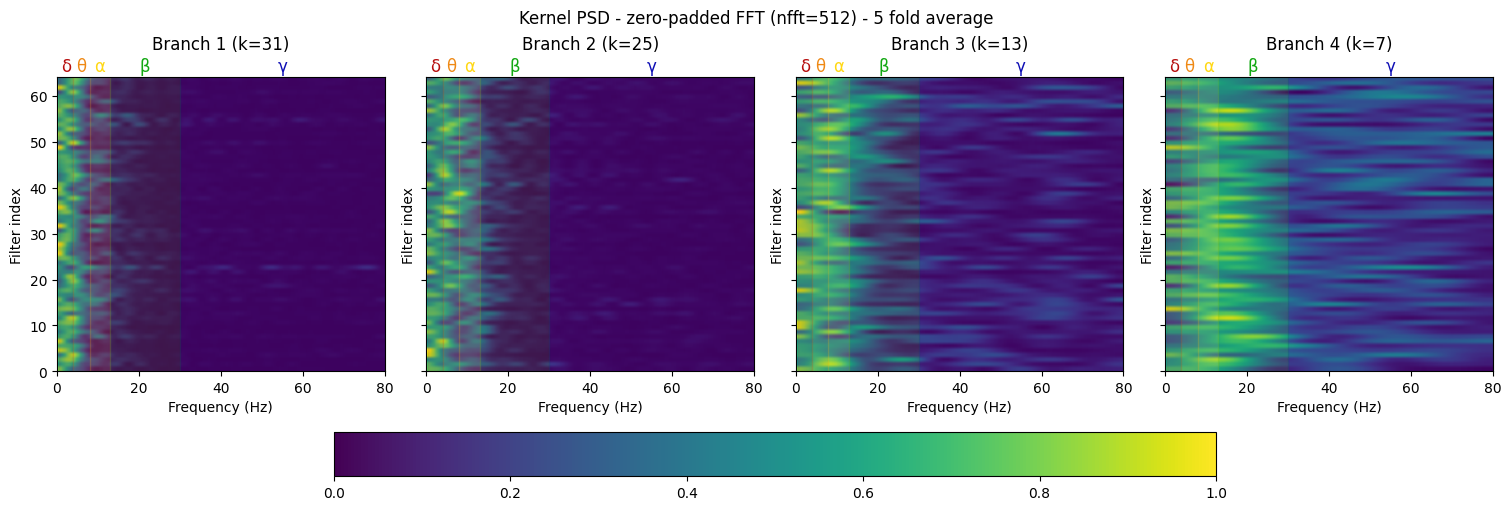

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from model import MultiBranchCNNLSTMv2 as MultiBranchCNNLSTM
from config import *

def plot_kernel_psd_heatmap(models, sfreq=160, nfft=512):
    """
    nfft >> kernel_size → zero-padding → risoluzione frequenziale fine
    per tutti i branch indipendentemente dal kernel size.
    """
    kernel_sizes = [31, 25, 13, 7]
    fig = plt.figure(figsize=(15, 5), constrained_layout=True)
    axes = fig.subplots(1, 4, sharey=True)
    
    bands = {'δ':(0.5,4), 'θ':(4,8), 'α':(8,13), 'β':(13,30), 'γ':(30,80)}
    band_colors = ["#b70e0e","#ef8914","#ffd814","#13a813","#0d0db4"]

    for branch_idx, ax in enumerate(axes):
        fft_stack = []
        for model in models:
            kernel = model.branches[branch_idx][0].block[0].weight.data.cpu().numpy()
            if kernel.ndim == 4:
                kernel = kernel.squeeze(2)  # (out_ch, in_ch, k)
            
            # media su in_ch → (out_ch, k)
            kernel_mean = kernel.mean(axis=1)
            
            # FFT con zero-padding → (out_ch, nfft//2+1)
            fft_mag = np.abs(np.fft.rfft(kernel_mean, n=nfft, axis=-1)) ** 2
            
            # normalizza per filtro
            fft_mag = (fft_mag - fft_mag.min(axis=1, keepdims=True)) / \
                      (fft_mag.max(axis=1, keepdims=True) - fft_mag.min(axis=1, keepdims=True) + 1e-8)
            fft_stack.append(fft_mag)
        
        fft_avg = np.stack(fft_stack).mean(axis=0)  # (out_ch, nfft//2+1)
        freqs = np.fft.rfftfreq(nfft, d=1/sfreq)
        
        # limita a 80 Hz
        freq_mask = freqs <= 80
        freqs_plot = freqs[freq_mask]
        fft_plot   = fft_avg[:, freq_mask]

        im = ax.imshow(fft_plot, aspect='auto',
                       extent=[freqs_plot[0], freqs_plot[-1], 0, fft_plot.shape[0]],
                       origin='lower', cmap='viridis', vmin=0, vmax=1)
        # plt.colorbar(im, ax=ax)

        # bande EEG
        for (name, (lo, hi)), color in zip(bands.items(), band_colors):
            ax.axvspan(lo, hi, alpha=0.12, color=color)
            ax.text((lo+hi)/2, fft_plot.shape[0]*1.02, name,
                    ha='center', fontsize=12, color=color)

        ax.set_title(f'Branch {branch_idx+1} (k={kernel_sizes[branch_idx]})', pad=20)
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('Filter index')
        ax.set_xlim(0, 80)

    fig.colorbar(im, ax=axes, location='bottom')
    fig.suptitle(f'Kernel PSD - zero-padded FFT (nfft={nfft}) - 5 fold average')
    # fig.tight_layout()
    fig.show()


# for each fold compute psd and show average fft.
models = []
for i in range(5):
    model_path = f'./models/model_f{i+1}_exp_LR0F_2s-b4.pth'
    m = MultiBranchCNNLSTM(4, int(2*SAMPLING_FREQ), kernel_list=[31,25,13,7]).to(DEVICE)
    m.load_state_dict(torch.load(model_path))
    m.eval()
    models.append(m)

plot_kernel_psd_heatmap(models, nfft=512)
plt.savefig('./Kernel-PSD.pdf')

In [7]:
m

MultiBranchCNNLSTMv2(
  (branches): ModuleList(
    (0): Sequential(
      (0): ConvBlock(
        (block): Sequential(
          (0): Conv1d(64, 64, kernel_size=(31,), stride=(1,), padding=same)
          (1): GroupNorm(8, 64, eps=1e-05, affine=True)
          (2): ReLU()
          (3): Conv1d(64, 64, kernel_size=(31,), stride=(1,), padding=same)
          (4): GroupNorm(8, 64, eps=1e-05, affine=True)
          (5): ReLU()
          (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        )
      )
      (1): ConvBlock(
        (block): Sequential(
          (0): Conv1d(64, 64, kernel_size=(31,), stride=(1,), padding=same)
          (1): GroupNorm(8, 64, eps=1e-05, affine=True)
          (2): ReLU()
          (3): Conv1d(64, 64, kernel_size=(31,), stride=(1,), padding=same)
          (4): GroupNorm(8, 64, eps=1e-05, affine=True)
          (5): ReLU()
          (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        )
     

## Activations to specific frequencies

[not interesting]

In [9]:
from datasets import SyntheticEEGDataset
from torch.utils.data import DataLoader

model_path = './models/model_f1_exp_LR_4s-b4.pth'
model = MultiBranchCNNLSTM(2, int(4*SAMPLING_FREQ),  kernel_list=[31,25,13,7]).to(DEVICE)
model.load_state_dict(torch.load(model_path))

res = []

for freq in [ (5), (6), (12), (22) ]:

    ds = SyntheticEEGDataset(
        n_samples  = 50,                        # per classe
        labels     = ['LEFT','RIGHT','FEET','REST'],
        freq_map   = {
            'LEFT'  : freq,                        # sinusoide pura a 10 Hz
            'RIGHT' : freq,                        # somma di freq casuali in [15,25] Hz
            'FEET'  : freq,                        # somma di 8+12+20 Hz
            'REST'  : freq,                        # molto lenta
        },
        window_sec = 4,
        sfreq      = 160,
        noise_std  = 0,
        n_channels = 64,
    )

    loader = DataLoader(ds, batch_size=50*4, shuffle=False)


    X_batch, _ = next(iter(loader))

    with torch.no_grad():
        acts = model.get_activations(X_batch.unsqueeze(1).to(DEVICE))
        # acts: (B, 1, n_feat, n_branches)

        # media su B e n_feat → (n_branches,)
        avg_act = acts.squeeze(1).mean(dim=(0, 1))  # (n_branches,)

        # attivazione relativa per branch → somma a 1
        rel_act = avg_act / avg_act.sum()

    res.append({'freq': freq, 'rel_act': rel_act.cpu().numpy()})
    print(f"freq={freq:3d}Hz | " + " | ".join(
        f"branch{i+1}: {v:.3f}" for i, v in enumerate(rel_act.cpu().numpy())
    ))



N-Branches : 4
[DEBUG][Synthetic] Macro 200 | Sub 200 | per class {'LEFT': 50, 'RIGHT': 50, 'FEET': 50, 'REST': 50}
         Shape X: torch.Size([200, 64, 640])  (n_samples*n_classes, C=64, L=640)
freq=  5Hz | branch1: 0.243 | branch2: 0.251 | branch3: 0.247 | branch4: 0.259
[DEBUG][Synthetic] Macro 200 | Sub 200 | per class {'LEFT': 50, 'RIGHT': 50, 'FEET': 50, 'REST': 50}
         Shape X: torch.Size([200, 64, 640])  (n_samples*n_classes, C=64, L=640)
freq=  6Hz | branch1: 0.241 | branch2: 0.248 | branch3: 0.249 | branch4: 0.262
[DEBUG][Synthetic] Macro 200 | Sub 200 | per class {'LEFT': 50, 'RIGHT': 50, 'FEET': 50, 'REST': 50}
         Shape X: torch.Size([200, 64, 640])  (n_samples*n_classes, C=64, L=640)
freq= 12Hz | branch1: 0.252 | branch2: 0.259 | branch3: 0.221 | branch4: 0.268
[DEBUG][Synthetic] Macro 200 | Sub 200 | per class {'LEFT': 50, 'RIGHT': 50, 'FEET': 50, 'REST': 50}
         Shape X: torch.Size([200, 64, 640])  (n_samples*n_classes, C=64, L=640)
freq= 22Hz | branch1